# ML-8 (Python) : Clustering non-supervisé avec K-Means

**Navigation** : [Index](README.md) | [<< Précédent](ML-7-Recommendation.ipynb) | [Jumeau .NET (ML.NET)](ML-8-Clustering.ipynb) | [Suivant >>](ML-9-Anomaly-Detection.ipynb)

> Ce notebook est le **jumeau Python (scikit-learn)** de [ML-8-Clustering.ipynb](ML-8-Clustering.ipynb). Il couvre exactement le même parcours pédagogique — segmentation RFM, K-Means, normalisation, méthode du coude, silhouette — avec l'API idiomatique de scikit-learn au lieu de ML.NET. Le clustering est un problème **non-supervisé** : on ne dispose d'aucune étiquette, l'algorithme doit découvrir seul la structure des données.

**Prérequis** : `scikit-learn`, `numpy`, `matplotlib` (CPU-viable, aucun GPU requis).


## Du supervisé au non-supervisé

Les notebooks précédents (ML-1 à ML-7) traitaient du **supervisé** : on dispose d'étiquettes cibles et l'objectif est d'apprendre une fonction f: X -> y. Le **clustering** bascule dans le régime **non-supervisé** :

- **Pas d'étiquette** `y` — seulement des features `X`.
- L'objectif est de **découvrir des groupes naturels** (clusters) dans les données, tels que les points d'un même cluster soient proches et les clusters soient séparés.

**K-Means** est l'algorithme canonique : il partitionne l'espace en K régions convexes (cellules de Voronoï) en assignant chaque point au centroïde le plus proche, puis en recalculant les centroïdes jusqu'à convergence.

Cas d'usage métier : **segmentation client RFM** (Recency, Frequency, Monetary) — identifier des segments (dormants, réguliers, VIP) pour cibler des campagnes marketing.


In [1]:
# Imports : numpy pour les données, scikit-learn pour le clustering et les métriques,
# matplotlib pour visualiser les segments trouvés.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.pipeline import Pipeline

# Graine fixée à 42 pour la reproductibilité (équivalent de MLContext(seed: 42) en ML.NET)
np.random.seed(42)
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["figure.dpi"] = 110

print("scikit-learn + numpy + matplotlib importés (seed fixée à 42)")


scikit-learn + numpy + matplotlib importés (seed fixée à 42)


## Jeu de données : segmentation RFM

On définit les trois variables RFM d'un client :

| Variable | Signification | Interprétation haute = ... |
|----------|---------------|----------------------------|
| **R**ecency | jours depuis le dernier achat | client dormant |
| **F**requency | achats par mois | client actif |
| **M**onetary | dépense moyenne par achat (EUR) | client à fort panier |

On génère **3 segments cachés** de 30 clients chacun, tirés de gaussiennes distinctes. Ces segments sont la vérité terrain que K-Means doit retrouver **sans** les connaître.


In [2]:
def next_gaussian(mean, std, n, rng=np.random):
    """Échantillonne n valeurs selon N(mean, std), clamées à >= 0 (équivalent de RandUtil.NextGaussian du jumeau .NET)."""
    return np.maximum(0.0, rng.normal(mean, std, size=n))

# 3 segments cachés × 30 clients
n = 30
recency_dorm = next_gaussian(85, 15, n); freq_dorm = next_gaussian(2, 1, n);  mon_dorm = next_gaussian(50, 20, n)
recency_regu = next_gaussian(30, 8,  n); freq_regu = next_gaussian(8, 2, n);  mon_regu = next_gaussian(150, 40, n)
recency_vip  = next_gaussian(8,  3,  n); freq_vip  = next_gaussian(20, 4, n); mon_vip  = next_gaussian(500, 100, n)

# Matrice X (90, 3) : colonnes = [Recency, Frequency, Monetary]
X = np.stack([
    np.concatenate([recency_dorm, recency_regu, recency_vip]),
    np.concatenate([freq_dorm,    freq_regu,    freq_vip]),
    np.concatenate([mon_dorm,     mon_regu,     mon_vip]),
], axis=1)

# Étiquette terrain (pour vérifier la qualité du clustering, NON fournie à K-Means)
y_terrain = np.array([0]*n + [1]*n + [2]*n)

print(f"Généré {X.shape[0]} clients × {X.shape[1]} features (Recency, Frequency, Monetary)")
print(f"  Segment 0 'Dormants' : Recency~{recency_dorm.mean():.0f}j, Freq~{freq_dorm.mean():.1f}, Mon~{mon_dorm.mean():.0f}EUR")
print(f"  Segment 1 'Réguliers': Recency~{recency_regu.mean():.0f}j, Freq~{freq_regu.mean():.1f}, Mon~{mon_regu.mean():.0f}EUR")
print(f"  Segment 2 'VIP'      : Recency~{recency_vip.mean():.0f}j, Freq~{freq_vip.mean():.1f}, Mon~{mon_vip.mean():.0f}EUR")


Généré 90 clients × 3 features (Recency, Frequency, Monetary)
  Segment 0 'Dormants' : Recency~82j, Freq~1.9, Mon~50EUR
  Segment 1 'Réguliers': Recency~30j, Freq~7.8, Mon~161EUR
  Segment 2 'VIP'      : Recency~8j, Freq~20.2, Mon~486EUR


## Pipeline : normalisation + K-Means

Deux étapes indispensables :

1. **Normalisation MinMax** (`MinMaxScaler`) — ramène chaque feature dans [0, 1]. Sans cela, `Monetary` (50 à 500 EUR) écraserait `Recency` et `Frequency` dans le calcul des distances euclidiennes, et le clustering refléterait surtout la dépense. C'est l'équivalent direct de `NormalizeMinMax` en ML.NET.
2. **K-Means** avec `n_clusters=3`, `random_state=42` (reproductibilité), `n_init=10` (10 redémarrages, on garde le meilleur).

L'API `scikit-learn` est composable : on chaîne le scaler et le K-Means dans un `Pipeline` pour éviter la fuite de données et sérialiser l'ensemble.


In [3]:
pipeline = Pipeline([
    ("scaler", MinMaxScaler()),                                    # équivalent NormalizeMinMax
    ("kmeans", KMeans(n_clusters=3, random_state=42, n_init=10)),  # K-Means K=3
])

print("Pipeline créé : MinMaxScaler -> KMeans(K=3)")


Pipeline créé : MinMaxScaler -> KMeans(K=3)


## Entraînement

On appelle `fit_predict` qui (a) ajuste le scaler sur `X`, (b) transforme `X` dans l'espace normalisé, (c) entraîne K-Means et (d) renvoie le label de cluster de chaque point.


In [4]:
labels = pipeline.fit_predict(X)
kmeans = pipeline.named_steps["kmeans"]
print(f"Modèle K-Means (K=3) entraîné : {len(labels)} points segmentés")
print(f"  Taille des clusters trouvés : {np.bincount(labels)}")


Modèle K-Means (K=3) entraîné : 90 points segmentés
  Taille des clusters trouvés : [30 30 30]


## Évaluation : inertie et séparation

Deux métriques non-supervisées :

| Métrique | Formule | Interprétation |
|----------|---------|----------------|
| **AverageDistance** (inertie intra-cluster) | distance moyenne de chaque point à son centroïde | **plus bas = clusters compacts** |
| **Davies-Bouldin Index** | moyenne du ratio dispersion/séparation entre paires de clusters | **plus bas = clusters bien séparés** |

> **Note de parité** : ML.NET expose `AverageDistance` (distance moyenne, non au carré). `scikit-learn` expose `inertia_` (somme des carrés). Pour comparer fidèlement, on calcule ici la **distance moyenne** manuellement, comme le jumeau .NET.


In [5]:
X_norm = pipeline.named_steps["scaler"].transform(X)
centroids = kmeans.cluster_centers_

# AverageDistance (fidèle à ML.NET) : distance euclidienne moyenne point -> son centroïde
avg_dist = np.mean(np.linalg.norm(X_norm - centroids[labels], axis=1))
# Davies-Bouldin : plus bas = mieux
db_index = davies_bouldin_score(X_norm, labels)

print("=== Métriques de clustering (K=3) ===")
print(f"  AverageDistance (inertie intra-cluster) : {avg_dist:.4f}")
print(f"  DaviesBouldinIndex (séparation)         : {db_index:.3f}")


=== Métriques de clustering (K=3) ===
  AverageDistance (inertie intra-cluster) : 0.1352
  DaviesBouldinIndex (séparation)         : 0.426


### Visualisation des 3 segments trouvés

K-Means retrouve les 3 segments cachés sans connaître `y_terrain` :


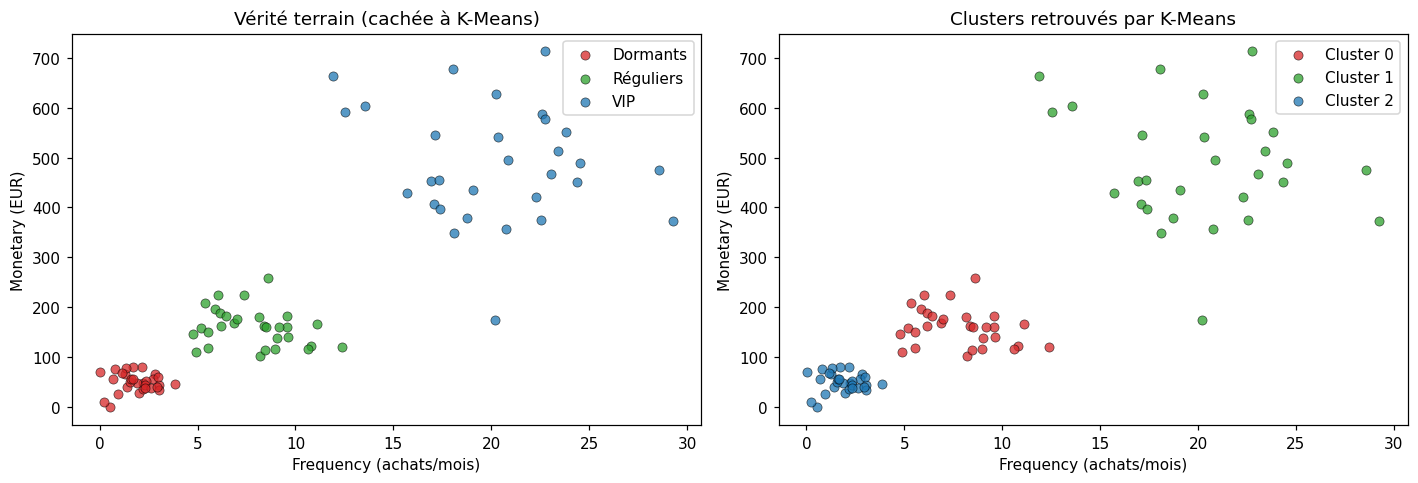

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

noms = {0: "Dormants", 1: "Réguliers", 2: "VIP"}
couleurs = ["#d62728", "#2ca02c", "#1f77b4"]

# Vue Vérité terrain (gauche)
for c in range(3):
    mask = y_terrain == c
    axes[0].scatter(X[mask, 1], X[mask, 2], c=couleurs[c], label=noms[c], alpha=0.75, edgecolor="k", linewidth=0.4)
axes[0].set_xlabel("Frequency (achats/mois)")
axes[0].set_ylabel("Monetary (EUR)")
axes[0].set_title("Vérité terrain (cachée à K-Means)")
axes[0].legend()

# Vue Clusters K-Means (droite)
for c in range(3):
    mask = labels == c
    axes[1].scatter(X[mask, 1], X[mask, 2], c=couleurs[c], label=f"Cluster {c}", alpha=0.75, edgecolor="k", linewidth=0.4)
axes[1].set_xlabel("Frequency (achats/mois)")
axes[1].set_ylabel("Monetary (EUR)")
axes[1].set_title("Clusters retrouvés par K-Means")
axes[1].legend()

plt.tight_layout()
plt.show()


## Prédiction : segmenter un nouveau client

On réutilise le pipeline entraîné pour prédire le segment de 3 profils types. La méthode `predict` applique la même normalisation (apprise sur `X`) puis assigne au centroïde le plus proche.


In [7]:
test_clients = np.array([
    [90, 1,  40 ],   # profil dormant
    [25, 9,  160],   # profil régulier
    [5,  22, 520],   # profil VIP
])

preds = pipeline.predict(test_clients)
print("=== Prédiction du segment de nouveaux clients ===")
for (r, f, m), p in zip(test_clients, preds):
    # distance normalisée aux 3 centroïdes (pour comparaison)
    x_norm = pipeline.named_steps["scaler"].transform([[r, f, m]])[0]
    dists = np.linalg.norm(centroids - x_norm, axis=1)
    dist_str = ", ".join(f"{d:.2f}" for d in dists)
    print(f"  Recency={r} Freq={f} Monetary={m}EUR -> Cluster {p}  (distances normalisées: [{dist_str}])")


=== Prédiction du segment de nouveaux clients ===
  Recency=90 Freq=1 Monetary=40EUR -> Cluster 2  (distances normalisées: [0.64, 1.19, 0.08])
  Recency=25 Freq=9 Monetary=160EUR -> Cluster 0  (distances normalisées: [0.06, 0.62, 0.62])
  Recency=5 Freq=22 Monetary=520EUR -> Cluster 1  (distances normalisées: [0.74, 0.08, 1.20])


## Choix de K : la méthode du coude

Comment choisir K quand on ne connaît pas le nombre de segments a priori ? On balaie K=2..6 et on observe deux indicateurs :

- **AverageDistance** : décroît avec K (plus de clusters = plus proches). On cherche le **coude** (point d'inflexion) où ajouter un cluster ne réduit plus beaucoup l'inertie.
- **Davies-Bouldin Index** : minimum global = meilleur K en termes de séparation.


=== Choix de K : méthode du coude (K=2..6) ===
  K | AverageDistance | DaviesBouldin
  --+-----------------+---------------
  2 |          0.2595 |         0.554
  3 |          0.1352 |         0.426
  4 |          0.1215 |         0.739
  5 |          0.1099 |         0.813
  6 |          0.1008 |         0.746


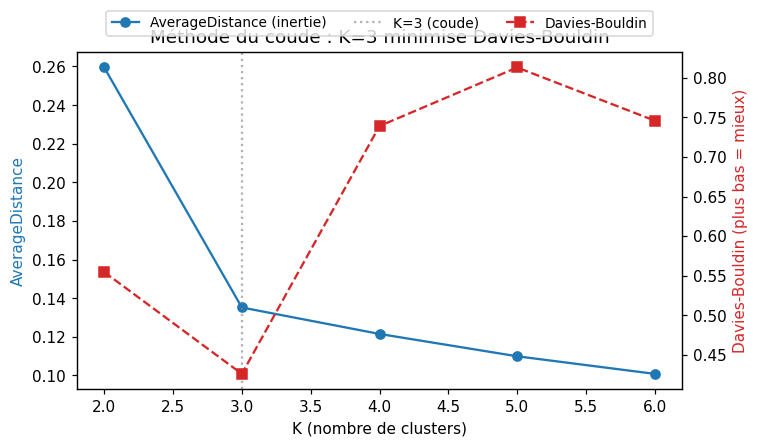

In [8]:
print("=== Choix de K : méthode du coude (K=2..6) ===")
print("  K | AverageDistance | DaviesBouldin")
print("  --+-----------------+---------------")
avg_dists, dbs = [], []
ks = range(2, 7)
for k in ks:
    sweep = Pipeline([
        ("scaler", MinMaxScaler()),
        ("kmeans", KMeans(n_clusters=k, random_state=42, n_init=10)),
    ])
    sweep_labels = sweep.fit_predict(X)
    Xn = sweep.named_steps["scaler"].transform(X)
    ctr = sweep.named_steps["kmeans"].cluster_centers_
    ad = np.mean(np.linalg.norm(Xn - ctr[sweep_labels], axis=1))
    db = davies_bouldin_score(Xn, sweep_labels)
    avg_dists.append(ad); dbs.append(db)
    print(f"  {k} | {ad:15.4f} | {db:13.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(ks), avg_dists, "o-", color="#1f77b4", label="AverageDistance (inertie)")
ax.set_xlabel("K (nombre de clusters)")
ax.set_ylabel("AverageDistance", color="#1f77b4")
ax2 = ax.twinx()
ax2.plot(list(ks), dbs, "s--", color="#d62728", label="Davies-Bouldin")
ax2.set_ylabel("Davies-Bouldin (plus bas = mieux)", color="#d62728")
ax.set_title("Méthode du coude : K=3 minimise Davies-Bouldin")
ax.axvline(3, color="gray", linestyle=":", alpha=0.6, label="K=3 (coude)")
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=3, fontsize=9)
plt.tight_layout()
plt.show()


### Interprétation : où est le coude ?

- L'**AverageDistance** chute fortement de K=2 à K=3 puis se stabilise : le coude est à **K=3**.
- Le **Davies-Bouldin Index** est minimal à K=3 : confirmation que 3 segments sont les mieux séparés.

Les deux indicateurs convergent vers K=3, ce qui correspond bien aux 3 segments cachés générés.


## Exercice 1 : Déterminer le K optimal sur un dataset à 4 segments

Générez un nouveau jeu de données avec **4 segments cachés** (4 × 25 points), puis cherchez le K optimal (K=2..7) avec la même boucle de sweep.

- **Indice** : recopiez la boucle de sweep ci-dessus sur `X4`. Le Davies-Bouldin minimum et le coude de l'AverageDistance doivent pointer vers K=4.


In [9]:
# Exercice 1 : Déterminer le K optimal sur un dataset à 4 segments
# TODO étudiant : génère 4 clusters cachés (4 x 25 points), puis cherche le K optimal (K=2..7)
# Étape 1 : génère un nouveau jeu X4 avec 4 segments distincts (Recency/Frequency/Monetary différents)
# Étape 2 : balaie K=2..7, entraîne KMeans, évalue (AverageDistance + DaviesBouldin)
# Étape 3 : affiche le K avec le DaviesBouldin minimum = ton K optimal
print("Exercice 1 à compléter")


Exercice 1 à compléter


## Exercice 2 : Calculer la silhouette moyenne (Rousseeuw, 1987)

La silhouette s(i) = (b(i) - a(i)) / max(a(i), b(i)) mesure la cohésion/séparation d'un point :

- a(i) = distance moyenne de i aux autres points de **son** cluster (cohésion)
- b(i) = distance moyenne de i au **cluster voisin le plus proche** (séparation)
- s(i) dans [-1, 1] ; proche de 1 = bien classé, proche de 0 = frontière, négatif = mal classé.

- **Indice** : `scikit-learn` fournit `silhouette_score(X_norm, labels)` directement. Implémentez-la à la main (double boucle sur les distances euclidiennes) puis comparez au score `sklearn`.


In [10]:
# Exercice 2 : Implémenter la silhouette moyenne (Rousseeuw, 1987)
# TODO étudiant : la silhouette s(i) = (b(i) - a(i)) / max(a(i), b(i))
#   a(i) = distance moyenne de i aux autres points de SON cluster
#   b(i) = distance moyenne de i au cluster voisin le plus proche
# Étape 1 : calcule la matrice des distances euclidiennes sur X_norm (double boucle ou scipy.spatial.distance)
# Étape 2 : pour chaque point, calcule a(i) puis b(i)
# Étape 3 : moyenne s(i) sur tous les points = silhouette globale
# Étape 4 : vérifie que K=3 maximise la silhouette (vs K=2, K=4) en comparant à sklearn.metrics.silhouette_score
print("Exercice 2 à compléter")


Exercice 2 à compléter


## Exercice 3 : Effet de la normalisation sur K-Means

Entraînez KMeans **sans** `MinMaxScaler` et comparez les clusters trouvés à la version normalisée.

- **Indice** : `Monetary` (50 à 500 EUR) domine totalement `Recency` et `Frequency` en échelle brute. Sans normalisation, le clustering reflète surtout la dépense.


In [11]:
# Exercice 3 : Effet de la normalisation sur K-Means
# TODO étudiant : entraîne KMeans SANS MinMaxScaler et compare les clusters trouvés.
# Étape 1 : construis un pipeline SANS scaler (KMeans direct sur X brut)
# Étape 2 : entraîne, évalue (AverageDistance, DaviesBouldin)
# Étape 3 : prédit les 3 test_clients et compare les clusters à la version normalisée
# Étape 4 : conclus : pourquoi la normalisation est-elle indispensable en clustering ?
print("Exercice 3 à compléter")


Exercice 3 à compléter


## Résumé

Ce notebook a introduit le **clustering K-Means non-supervisé** en Python :

| Concept | Description |
|---------|-------------|
| Non-supervisé | Pas d'étiquette `y` ; l'algorithme découvre seul les groupes |
| K-Means | Partitionne en K cellules de Voronoï (assignation au centroïde le plus proche) |
| Normalisation | `MinMaxScaler` indispensable pour que chaque feature pèse également |
| AverageDistance | Distance moyenne point->centroïde (compacité) |
| Davies-Bouldin | Ratio dispersion/séparation (plus bas = mieux) |
| Méthode du coude | Balayer K et chercher l'inflexion de l'inertie + le min Davies-Bouldin |

**Parité ML.NET vs scikit-learn** :

| ML.NET (.NET) | scikit-learn (Python) |
|---------------|------------------------|
| `NormalizeMinMax` | `MinMaxScaler` |
| `Clustering.Trainers.KMeans` | `KMeans(n_clusters=K, random_state=42)` |
| `Evaluate().AverageDistance` | distance moyenne calculée (`.inertia_` = somme des carrés) |
| `Evaluate().DaviesBouldinIndex` | `davies_bouldin_score` |
| `CreatePredictionEngine().Predict` | `pipeline.predict` |


## Références

**Algorithme (K-Means et métriques de clustering)**

- MacQueen, J. (1967). *Some methods for classification and analysis of multivariate observations*. Berkeley Symposium.
- Rousseeuw, P. J. (1987). *Silhouettes: a graphical aid to the interpretation and validation of cluster analysis*. Computational and Applied Mathematics, 20, 53-65.
- Davies, D. L., & Bouldin, D. W. (1979). *A cluster separation measure*. IEEE TPAMI.

**Documentation scikit-learn**

- [`sklearn.cluster.KMeans`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)
- [`sklearn.metrics.silhouette_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html)
- [`sklearn.metrics.davies_bouldin_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.davies_bouldin_score.html)

**Jumeau .NET** : [ML-8-Clustering.ipynb](ML-8-Clustering.ipynb) (ML.NET, API équivalente).
